# Analiza comparativă a modelelor de regresie pentru predicția costurilor medicale

## 1. Definirea problemei

În acest notebook este analizată o problemă de regresie, având ca scop predicția costurilor medicale individuale pe baza unor caracteristici medicale demografice și personale ale pacienților.

Variabila țintă este `charges`, care reprezintă costurile medicale facturate. Variabilele de intrare sunt `age`, `sex`, `bmi`, `children`, `smoker` și `region`.

Problema are relevanță practică deoarece estimarea costurile medicale poate fi utilă în analiza riscului, în înțelegerea factorilor care influențează cheltuielile de sănătate și în construirea unor modele predictive pentru domeniul asigurărilor medicale.

Am ales acest set de date deoarece este potrivit pentru o problmeă de regresie, conține atât variabile numerice, cât și variabile categoriale, și permite compararea mai multor algoritmi de machine learning.

### Relevanța practică a problemei

Această problemă este relevantă deoarece estimarea costurilor medicale poate fi utilă în domeniul asigurărilor și al planificării financiare. Pe baza unor caracteristici precum vârsta, indicele de masă corporală, statutul de fumător sau regiunea, un model de regresie poate estima valoarea costurilor medicale facturate.

Am ales această problemă deoarece este un exemplu bun pentru regresie, având o variabilă numerică de ieșire și mai multe caracteristici care pot influența rezultatul. În plus, setul de date permite compararea mai multor modele și interpretarea influenței variabilelor asupra predicțiilor.

### Variabila de ieșire

Varibaila de ieșire este `charges`, care reprezintă costurile medicale facturate pentru fiecare persoană din setul de date. Aceasta este o varibilă numerică exprimată în unități monetare, iar obiectivul modelelor de regresie esre estimarea cât mai precisă a acestei valori pe baza caracteristicilor disponibile.

Deoarece valoarea prezisă este numericp și continua, problema este una de regresie.

## 2. Obiectivul analizei

Scopul analizei este antrenarea, evaluarea și compararea mai multor modele de regresie pentru predicția variabilei `charges`. Vor fi analizate atât performanțele modelelor de bază, cât și versiunile optimizate ale celor mai bune modele, folosind metrici specifice regresiei, curbe de învățare și metode de explicabilitate precum SHAP.

## 3. Încărcarea și inspectarea inițială a datelor

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [3]:
print("Shape:", df.shape)

display(df.info())

print("Valori lipsa:")
display(df.isnull().sum())

print("\nLinii duplicate:", df.duplicated().sum())

Shape: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


None

Valori lipsa:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Linii duplicate: 1


In [4]:
print("Tipuri de date:")
display(df.dtypes)

print("\nStatistici descriptive pentru variabilele numerice:")
display(df.describe().T)

print("\nStatistici descriptive pentru variabilele categoriale:")
display(df.describe(include="object").T)

Tipuri de date:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


Statistici descriptive pentru variabilele numerice:


,count,mean,std,min,25%,50%,75%,max
age,1338.000,39.207,14.050,18.000,27.000,39.000,51.000,64.000
bmi,1338.000,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,1.095,1.205,0.000,0.000,1.000,2.000,5.000
charges,1338.000,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428



Statistici descriptive pentru variabilele categoriale:


C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\3678877265.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [5]:
print("Intervalul valorilor pentru variabila tinta:")
print("Minim:", df["charges"].min())
print("Maxim:", df["charges"].max())

Intervalul valorilor pentru variabila tinta:
Minim: 1121.8739
Maxim: 63770.42801


## 4. Curățarea datelor

Înainte de analiza propriu-zisă, verificăm dacă setul de date conține valori lipsă, duplicate sau valori care trebuie tratate înainte de antrenarea modelelor. Această etapă este necesară pentru a evita introducerea unor erori în procesul de învățare. 

In [6]:
df_clean = df.copy()

print("Valori lipsa pe coloane:")
display(df_clean.isnull().sum())

print("Numar de duplicate:", df_clean.duplicated().sum())

Valori lipsa pe coloane:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Numar de duplicate: 1


In [7]:
df_clean = df_clean.drop_duplicates()

print("Shape dupa eliminarea duplicatelor:", df_clean.shape)

Shape dupa eliminarea duplicatelor: (1337, 7)


Setul de date nu conține valori lipsă, ceea ce înseamnă că nu este necesară imputarea. A fost identificată o singură linie duplicată, care a fost eliminată pentru a evita influențarea artificială a modelelor.

## 5. Analiza exploratorie a datelor

În această etapă analizăm distribuția variabilei țintp, structura variabilelor numerice și categoriale, precum și relațiile principale dintre caracteristici și costurile medicale

In [8]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

### 5.1 Distribuția variabilei țintă

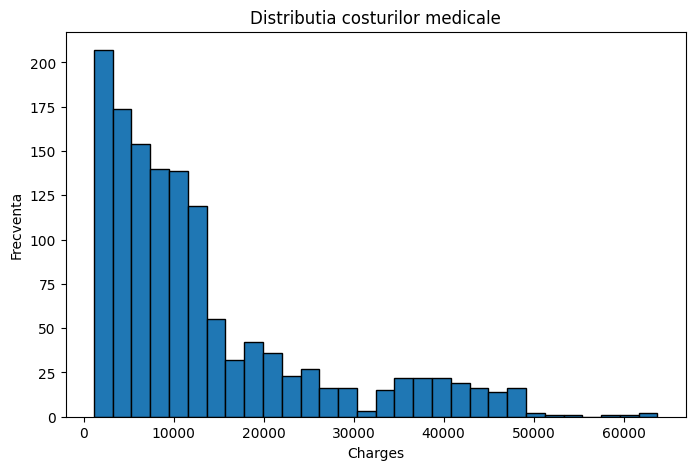

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["charges"], bins=30, edgecolor="black")
plt.title("Distributia costurilor medicale")
plt.xlabel("Charges")
plt.ylabel("Frecventa")
plt.show()

Distribuția variabilei `charges` este asimetrică spre dreapta. Cele mai multe persoane au costuri medicale relativ reduse, însă există și observații cu valori mult mai mari. Acest lucru poate influența modelele de regresie, deoarece valorile mari pot crește erorile precum MSE și RMSE.

### 5.2 Distribuția variabilelor numerice

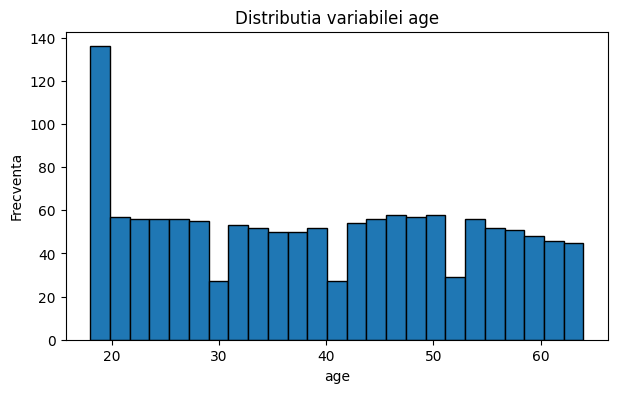

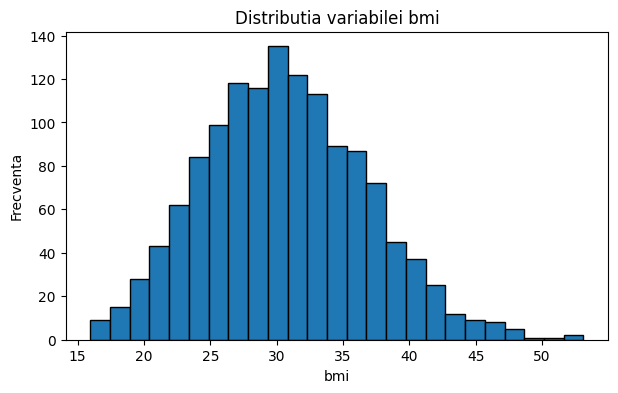

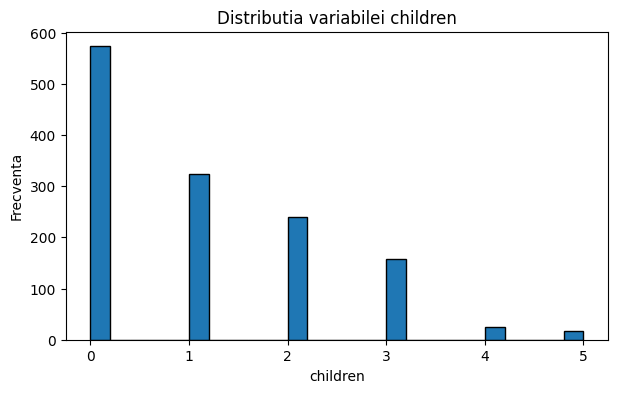

In [10]:
for col in ["age", "bmi", "children"]:
    plt.figure(figsize=(7, 4))
    plt.hist(df_clean[col], bins=25, edgecolor="black")
    plt.title(f"Distributia variabilei {col}")
    plt.xlabel(col)
    plt.ylabel("Frecventa")
    plt.show()

Variabila `age` este distribuită pe un interval larg de vârste, iar `bmi` are o distribuție aproximativ concentrată în jurul valorilor medii. Variabila `children` are valori discrete, majoritatea persoanelor având un număr redus de copii.

### 5.3 Distribuția variabilelor categoriale

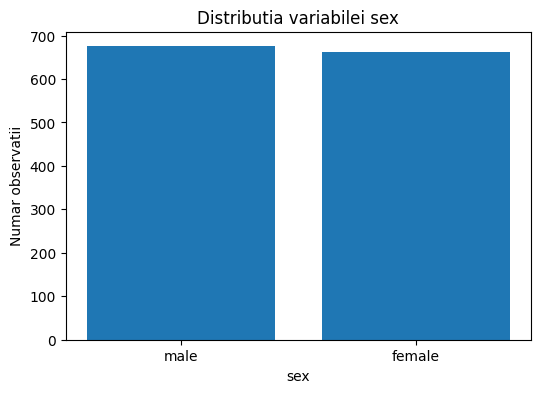

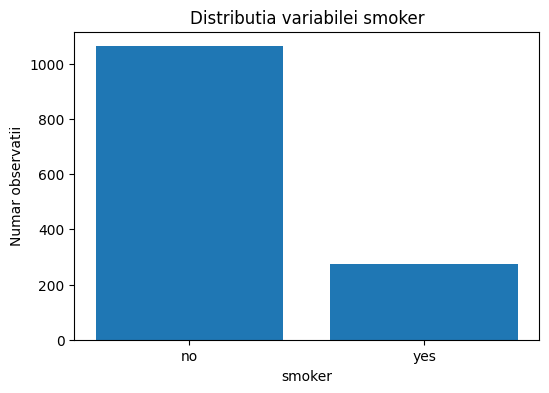

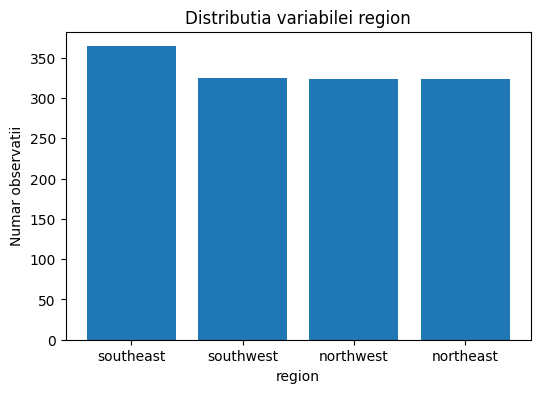

In [11]:
for col in categorical_cols:
    counts = df_clean[col].value_counts()

    plt.figure(figsize=(6, 4))
    plt.bar(counts.index, counts.values)
    plt.title(f"Distributia variabilei {col}")
    plt.xlabel(col)
    plt.ylabel("Numar observatii")
    plt.show()

Variabilele categoriale sunt ușor de interpretat. Setul de date conține persoane fumătoare și nefumătoare, persoane de ambele sexe și observații din patru regiuni. Distribuția fumătorilor este dezichilibrată, numărul nefumătorilor fiind mai mare.

### 5.4 Relația dintre variabilele numerice și costurile medicale

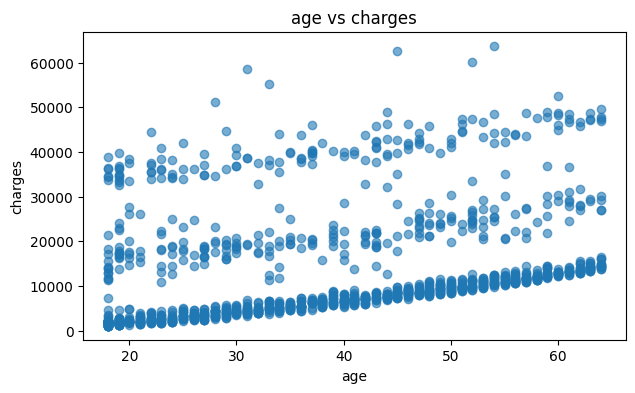

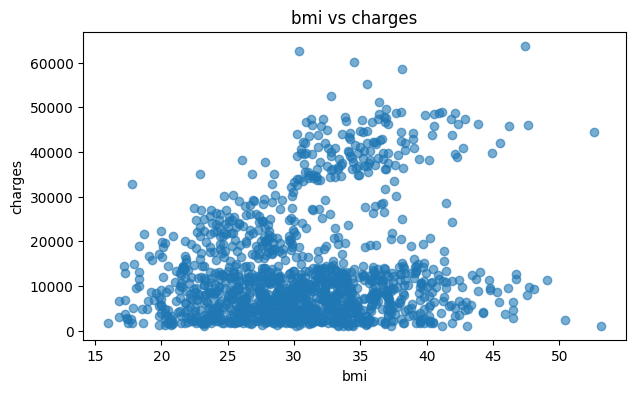

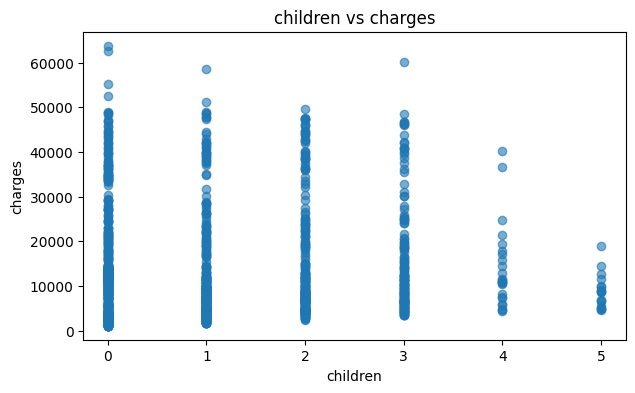

In [12]:
features_num = ["age", "bmi", "children"]

for col in features_num:
    plt.figure(figsize=(7, 4))
    plt.scatter(df_clean[col], df_clean["charges"], alpha=0.6)
    plt.title(f"{col} vs charges")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()

Se observă relații diferite între variabilele numerice și costurile medicale. Vârsta pare să aibă o influență pozitivă asupra costurilor, persoanele mai în vârstă având în general cheltuieli mai ridicate. Variabila `bmi` prezintă de asemenea o asociere pozitivă, iar `children` pare să aibă o influență mai redusă.

### 5.5 Relația dintre variabilele categoriale și costurile medicale

C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\2810741337.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


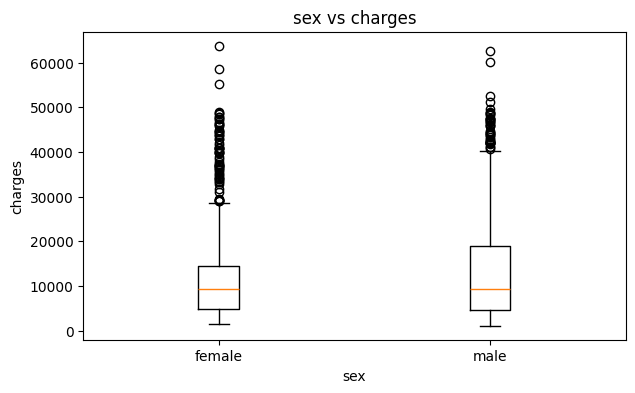

C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\2810741337.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


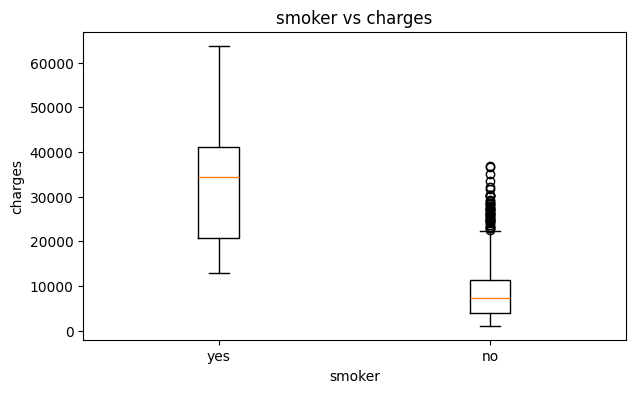

C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\2810741337.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


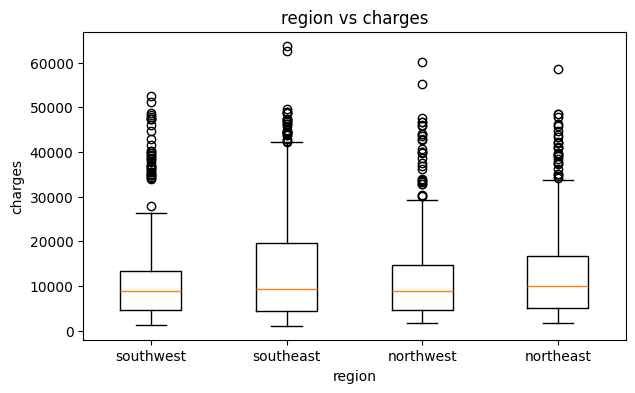

In [13]:
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    categories = df_clean[col].unique()
    data = [df_clean[df_clean[col] == cat]["charges"] for cat in categories]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=categories)
    plt.title(f"{col} vs charges")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()

Cea mai puternică diferență apare în cazul variabilei `smoker`. Persoanele fumătoare au costuri medicale semnificativ mai mari decât nefumătorii. Variabilele `sex` și `region` par să aibă o influență mai redusă asupra costurilor.

### 5.6 Corelația variabilelor numerice

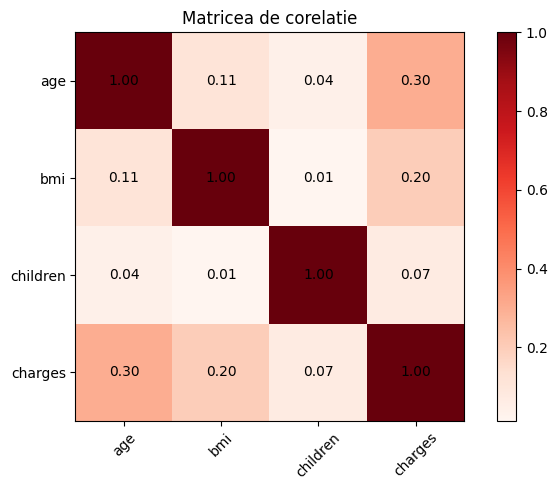

In [14]:
corr = df_clean[["age", "bmi", "children", "charges"]].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="Reds")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Matricea de corelatie")
plt.tight_layout()
plt.show()

Variabila `charges` este corelată moderat cu `age` și într-o măsură mai redusă cu `bmi`. Corelația liniară nu surprinde însă complet influența variabilelor categoriale precum `smoker`, care pare foarte importantă.

## 6. Concluzii după analiza exploratorie

Setul de date este curat și potrivit pentru modelare. Nu conține valori lipsă, iar numărul de duplicate a fost eliminat.

Cele mai importante observații rezultate în urma EDA sunt:

- costurile medicale au distribuție asimetrică spre dreapta;
- vârsta și indicele BMI influențează pozitiv costurile
- statutul de fumător este un factor determinant major;
- variabilele categoriale trebuie codificate înainte de antrenarea modelelor.

În continuare, datele vor fi pregătite pentru modelele de machine learning.

## 7. Pregătirea datelor pentru modelare

Înainte de antrenarea modelelor, separăm variabila țintă de variabilele de intrare și împărțim datele în set de antrenare și set de testare. Voi folosi 75% din date pentru antrenare și 25% pentru testare. 

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X = df_clean.drop("charges", axis=1)
y = df_clean["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test", y_test.shape)

X_train: (1002, 6)
X_test: (335, 6)
y_train: (1002,)
y_test (335,)


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Variabilele numerice sunt scalate folosind `StandardScaler`, iar variabilele categoriale prin `OneHotEncoder`. Pentru a evita scurgerile de informație din setul de testare către cel de antrenare, aceste transformări sunt incluse într-un `Pipeline`.

## 8. Antrenarea și compararea modelelor de bază

Sunt testate mai mulți algoritmi de regresie folosind setările implicite, pentru a observa diferențele de performanță dintre metode înainte de optimizarea hiperparametrilor.

Evaluarea se face pe setul de testare folosind următoarele metrici:

- **Mean Square Error (MSE)** - media pătratelor erorilor dintre valorile reale și cele prezise; penalizeaza mai pueternic abaterile mari.
- **Mean Absolute Error (MAE)** - media valorilor absolute ale erorilor; indică abaterea medie a predicțiilor.
- **Root Mean Squared Error (RMSE)** - rădăcina pătrată a MSE; exprimă eroarea în aceeași unitate ca variabila țintă.
- **Coefficient of Determination (R^2)** - măsoară proporția variației variabilei țintă explicată de model.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Foresr Regressor": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Neareste Neighbors Regressor": KNeighborsRegressor(),
    "Gaussian Process Regressor": GaussianProcessRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42, verbosity=0),
    "CatBoost Regressor": CatBoostRegressor(random_state=42, verbose=0),
    "Explainable Boosting Regressor": ExplainableBoostingRegressor(random_state=42)
}

In [19]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": round(mse, 2),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R^2": round(r2, 4)
    })

In [20]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R^2", ascending=False).reset_index(drop=True)

results_df

,Model,MSE,MAE,RMSE,R^2
0,Explainable Boosting Regressor,19533305.930,2557.970,4419.650,0.887
1,CatBoost Regressor,21396007.780,2624.660,4625.580,0.876
2,Random Foresr Regressor,22386279.860,2615.360,4731.410,0.871
3,XGBoost Regressor,26040542.210,2920.970,5102.990,0.849
4,Linear Regression,35283922.770,4069.040,5940.030,0.796
5,Decision Tree Regressor,35972916.460,2754.630,5997.740,0.792
6,K-Neareste Neighbors Regressor,38419573.370,3737.400,6198.350,0.778
7,Support Vector Regressor,193430373.600,8901.270,13907.920,-0.119
8,Gaussian Process Regressor,446159289232.280,188028.780,667951.560,-2579.300


## 10. Interpretarea rezultatelor inițiale

Tabelul de mai sus evidențiază diferențele de performanță dintre algoritmii testați.

Modelele bazate pe boosting și esemble obțin cele mai bune rezultate, ceea ce sugerează prezența unor relații neliniare între variabilele explicative și costurile medicale.

Regresia liniară rămâne un reper util, însă performanța sa este mai redusă comparativ cu modelele mai flexibile.

Primele cinci modele sunt selectate pentru etapa următoare de optimizare.

In [21]:
top5_models = results_df.head(5)
top5_models

,Model,MSE,MAE,RMSE,R^2
0,Explainable Boosting Regressor,19533305.930,2557.970,4419.650,0.887
1,CatBoost Regressor,21396007.780,2624.660,4625.580,0.876
2,Random Foresr Regressor,22386279.860,2615.360,4731.410,0.871
3,XGBoost Regressor,26040542.210,2920.970,5102.990,0.849
4,Linear Regression,35283922.770,4069.040,5940.030,0.796


## 11. Optimizarea hiperparametrilor

După compararea modelelor de bază, au fost selectate primele cinci modele în funcție de scorul R^2:

1. Explainable Boosting Regressor
2. CatBoost Regressor
3. Random Forest Regressor
4. XGBoost Regressor
5. Linear Regression

Aceste modele vor fi optimizate prin `GridSearchCV`, folosind validare încrucișată cu 5 fold-uri. Scopul este identificarea unor combinații de hiperparametri care îmbunătățesc performanța fără a favoriza supraînvățarea.

Pentru fiecare model au fost alese intervale restrânse de valori, astfel încât procesul de căutare să fie eficient și să compare variante realiste ale fiecărui algoritm.

### 11.1 Explainable Boosting Regressor

Pentru Explainable Boosting Regressor sunt ajustați hiperparametri care controlează complexitatea modelului și ritmul de învățare. `max_bins` influențează modul în care sunt discretizate variabilele, `learning_rate` controlează dimensiunea pașilor de învățare, iar `max_rounds` stabilește numărul maxim de iterații.

In [22]:
from sklearn.model_selection import GridSearchCV

ebm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExplainableBoostingRegressor(random_state=42))
])

ebm_params = {
    "model__max_bins": [128, 256],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_rounds": [300, 500]
}

ebm_grid = GridSearchCV(ebm_pipe, ebm_params, cv=5, scoring="r2", n_jobs=-1)

_ = ebm_grid.fit(X_train, y_train)

In [23]:
ebm_grid.best_params_

{'model__learning_rate': 0.01,
 'model__max_bins': 256,
 'model__max_rounds': 300}

In [24]:
ebm_grid.best_score_

np.float64(0.8418098904544337)

## Observații

Pentru Explainable Boosting Regressor, cea mai bună configurație a fost obținută cu `learning_rate = 0.01`, `max_bins = 256` și `max_rounds = 300`.

Scorul mediu R^2 obținut prin validare încrucișate este aproximativ `0.842`. Acest rezultat indică o capacitate bună de generalizare, însă performanța finală trebuie verificată separat pe setul de testare.

### 11.2 CatBoost Regressor

Pentru CatBoost sunt ajustați hiperparametri legațo de adâncimea arborilor, rata de învățare și numărul de iterații. Acesști parametri controlează cât de complex devine modelul și cât de rapid învață din date.

In [25]:
cat_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(verbose=0, random_state=42))
])

cat_params = {
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.05],
    "model__iterations": [300, 500]
}

cat_grid = GridSearchCV(
    cat_pipe,
    cat_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

_ = cat_grid.fit(X_train, y_train)

In [26]:
cat_grid.best_params_

{'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.03}

In [27]:
cat_grid.best_score_

np.float64(0.8455201847833272)

## Observații

Cea mai bună configurație pentru CatBoost Regressor a fost obținută cu `depth = 4`, `iterations = 300` și `learning_rate = 0.03`.

Scorul mediu R^2 obținut prin validare încrucișată este aproximativ `0.846`, ceea ce indică o capacitate bună de generalizare și o performanță competitivă față de celelalte modele analizate.

### 13.3 Random Forest Regressor

Pentru Random Forest Regressor sunt ajustați hiperparametri care controlează numărul de arbori și complexitatea acestora. Un număr mai mare de arbori poate crește stabilitatea modelului, iar limitarea adâncimii poate reduce supraînvățarea.

In [28]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [10, None],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

_ = rf_grid.fit(X_train, y_train)

In [29]:
rf_grid.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 5,
 'model__n_estimators': 200}

In [30]:
rf_grid.best_score_

np.float64(0.8303107603731874)

## Observații

Cea mai bună configurație pentru Random Forest Regressor a fost obținută cu `n_estimators = 200`, `max_depth = 10` și `min_samples_split = 5`.

Scorul mediu R^2 obținut prin validare încrucișată este aproximativ `0.830`, ceea ce indică o performanță bună, însă ușor inferioară modelelor boosting machine anterioare.

### 11.4 XGBoost Regressor

Pentru XGBoost sunt testați hiperparametri care influențează complexitatea arborilor și ritmul de învățare. Alegerea atentă a acestor valori este importantă pentru obținerea unui model performant fără supraînvățare.

In [31]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_dtate=42, verbosity=0))
])

xgb_params = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.05]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

_ = xgb_grid.fit(X_train, y_train)

In [32]:
xgb_grid.best_params_

{'model__learning_rate': 0.03,
 'model__max_depth': 3,
 'model__n_estimators': 200}

In [33]:
xgb_grid.best_score_

np.float64(0.8458632471455032)

## Observații

Cea mai bună configurație pentru XGBoost Regressor a fost obținutp cu `learning_rate = 0.03`, `max_depth = 3` și `n_estimators = 200`.

Scorul mediu R^2 obținut prin validare încrucișată este aproximativ `0.846`, ceea ce indică o capacitate foarte bună de generalizare și una dintre cele mai ridicate performanțe modelele analizatee.

### 11.5 Linear Regression

Linear Regression nu necesită ajustări complexe ale hiperparametrilor în forma standard. Este păstrată în comparația finală ca model de referință, pentru a observa diferența dintre metodele simple și algoritmii mai avansați.

In [34]:
lin_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

from sklearn.model_selection import cross_val_score

lin_score = cross_val_score(
    lin_pipe,
    X_train,
    y_train,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

lin_score.mean()

np.float64(0.723735296687244)

## Observații 

Scorul mediu R^2 obținut de modelul Linear Regression prin validare încrucișată este aproximativ `0.724`.

Rezultatul confirmă faptul că relația dintre variabilele explicative și costurile medicale nu este strict liniară, iar modelele capabile să surprindă relații neliniare oferă performanțe ridicate.

## 11.6 Compararea modelelor optimizate

In [35]:
tuned_results = pd.DataFrame({
    "Model": [
        "Explainable Boosting Regressor",
        "CatBoost Regressor",
        "Random Forest Regressor",
        "XGBoost Regressor",
        "Linear Regression"
    ],

    "Best R^2 (CV)": [
        0.8418,
        0.8455,
        0.8303,
        0.8459,
        0.7237
    ]
})

tuned_results = tuned_results.sort_values(
    by="Best R^2 (CV)",
    ascending=False
).reset_index(drop=True)

tuned_results

,Model,Best R^2 (CV)
0,XGBoost Regressor,0.846
1,CatBoost Regressor,0.846
2,Explainable Boosting Regressor,0.842
3,Random Forest Regressor,0.830
4,Linear Regression,0.724


Rezultatele arată că cele mai bune performanțe au fost obținute de modelele boosting.

XGBoost Regressor ocupă prima poziție, urmat foarte aproape de CatBoost Regressor și Explainable Boosting Regressor.

Random Forest oferă rezultate solide, însă ușor inferioare metodelor boosting, iar Linear Regression rămâne semnificativ în urmă.

Diferențele confirmă faptul că problema analizată implică relații neliniare și interacțiuni între variabile, care sunt surprinse mai eficient de modelele ensemble moderne.

Astfel, în urma optimizării hiperparametrilor, modelul selectat pentru etapele următoare este **XGBoost Regressor**, deoarece a obținut cel mai ridicat scor R^2 și prezintă o capacitate bună de generalizare. 

## 12. Curbele de învățare

Curbele de învățare arată modul în care performanța modelelor evoluează pe măsură ce crește numărul exemplelor de antrenare.

Sunt analizate atât scorurile obținute pe datele de antrenare, cât și cele obșținute prin validare încrucișată. Diferența dintre cele două curbe oferă informații importante despre capacitatea de generalizare a fiecărui model.

In [36]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, title):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
    plt.title(title)
    plt.xlabel("Numar exemple antrenare")
    plt.ylabel("R^2 score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [37]:
best_ebm = ExplainableBoostingRegressor(
    random_state=42,
    learning_rate=0.01,
    max_bins=256,
    max_rounds=300
)

best_cat = CatBoostRegressor(
    random_state=42,
    verbose=0,
    depth=4,
    iterations=300,
    learning_rate=0.03
)

best_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    max_depth=10,
    min_samples_split=5
)

best_xgb = XGBRegressor(
    random_state=42,
    verbosity=0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=200
)

best_lin = LinearRegression()

### 12.1 Explainable Boosting Regressor

Explainable Boosting Regressor este un model de tip boosting interpretabil, construit pentru a combina performanța ridicată cu transparența deciziilor.

Curba de învățare este analizată pentru a observa dacă modelul generalizează bine și dacă existp semne de supraînvățare.

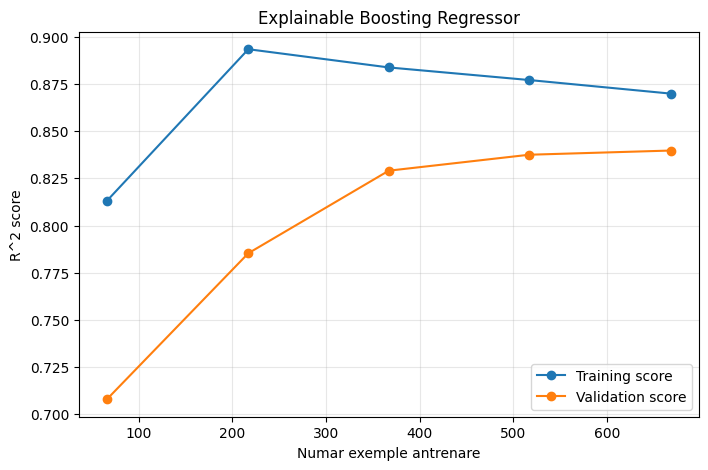

In [38]:
plot_learning_curve(best_ebm, "Explainable Boosting Regressor")

### 12.2 CatBoost Regressor

CatBoost este un algoritm de boosting performant, eficient în special în prezența variabilelor categoriale și a relațiilor complexe dintre caracteristici.

Curba de învățare permite evaluarea stabilității modelului și a diferenței dintre scorul de antrenare și cel de validare.

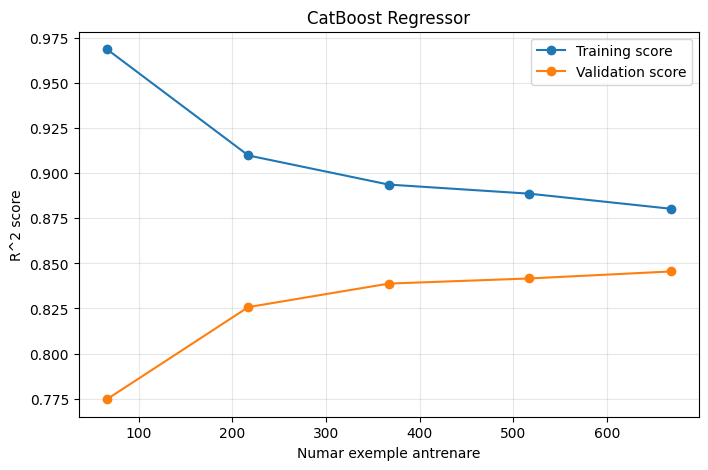

In [39]:
plot_learning_curve(best_cat, "CatBoost Regressor")

### 12.3 Random FOrest Regressor

Random Forest combină mai mulți arbori de decizie pentru a reduce variația și a îmbunătăți predicțiile.

Prin curba de învățare se poate observa dacă modelul tinde să memoreze datele de antrenare sau dacă generalizează eficient.

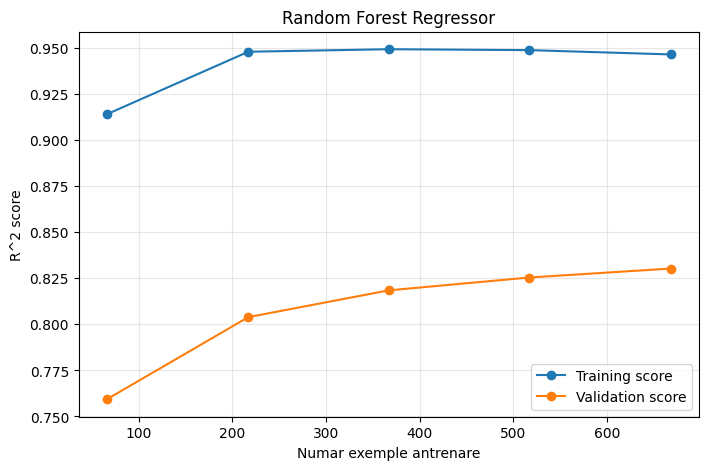

In [40]:
plot_learning_curve(best_rf, "Random Forest Regressor")

### 12.4 XGBoost Regressor

XGBoost este unul dintre cei mai utilizați algoritmi ensemble datorită performanței ridicate și controlului bun al complexității.

Curba de învățare este utilă pentru a analiza echilibrul dintre performanță și overfitting.

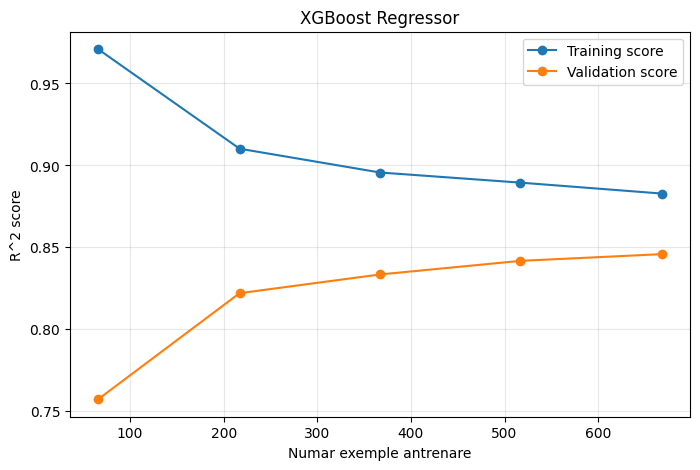

In [41]:
plot_learning_curve(best_xgb, "XGBoost Regressor")

### 12.5 Linear Regression

Linear Regression reprezintă modelul de referință, bazat pe relații liniare între variabile.

Curba de învățare indică dacă modelul este suficient de flexibil pentru problema analizată sau dacă apare undefitting.

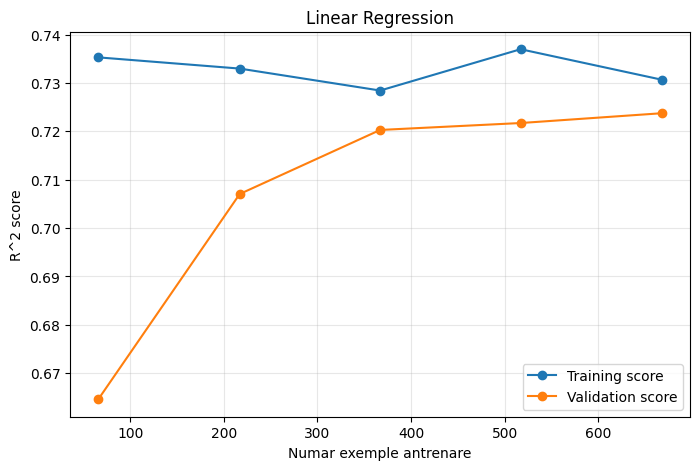

In [42]:
plot_learning_curve(best_lin, "Linear Regression")

## 12.3 Sinteză privind comportamentul modelelor

| Model | Situație principală observată |
|------|-------------------------------|
| Explainable Boosting Regressor | Generalizare bună și diferență redusă între scoruri |
| CatBoost Regressor | Ușor overfitting la volume mici de date, apoi stabilizare |
| Random Forest Regressor | Tendință moderată de overfitting |
| XGBoost Regressor | Echilibru foarte bun între performanță și generalizare |
| Linear Regression | Underfitting, model prea simplu pentru relațiile din date |

## 13. Explicabilitatea modelelor folosind SHAP

Pentru interpretarea modelelor optimizate este folosită analiza SHAP, care permite observarea contribuției fiecărei caracteristici asupra predicțiilor.

Sunt analizate primele trei modele perfecționate, deoarece acestea au obținut cele mai bune rezultate după optimizarea hiperparametrilor:

1. XGBoost Regressor
2. CatBoost Regressor
3. Explainable Boosting Regressor

Analiza urmărește atât interpretarea globală a modelelor, cât și explicații locale pentru predicții individuale.

In [43]:
import shap

final_models = {
    "XGBoost Regressor": best_xgb,
    "CatBoost Regressor": best_cat,
    "Explainable Boosting Regressor": best_ebm
}

In [44]:
fitted_models = {}

for name, model in final_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

In [45]:
feature_names = fitted_models["XGBoost Regressor"] \
    .named_steps["preprocessor"] \
    .get_feature_names_out()

X_test_transformed = fitted_models["XGBoost Regressor"] \
    .named_steps["preprocessor"] \
    .transform(X_test)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_sample = X_test_transformed.sample(100, random_state=42)

### 13.1 Analiza SHAP pentru XGBoost Regressor

XGBoost Regressor a fost modelul cu cea mai bună performanță după optimizarea hiperparametrilor, motiv pentru care este analizat în detaliu prin SHAP.

Metoda SHAP permite interpretarea atât globală a modelului, cât și locală, la nivelul unei predicții individuale.

In [46]:
xgb_model = fitted_models["XGBoost Regressor"].named_steps["model"]

xgb_explainer = shap.Explainer(xgb_model, X_test_sample)
xgb_shap_values = xgb_explainer(X_test_sample)

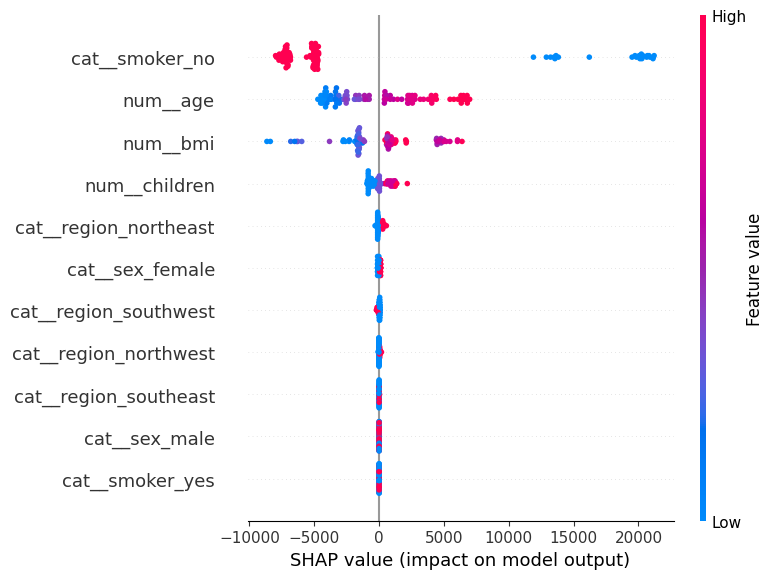

In [47]:
shap.summary_plot(xgb_shap_values, X_test_sample)

### Importanța globală a caracteristicilor

Din summary plot se observă că cele mai influente variabile în procesul de predicție sunt:

1. `cat__smoker_no`
2. `num__age`
3. `num__bmi`

Aceste caracteristici au cel mai mare impact asupra valorii estimate a costurilor medicale.

Valorile SHAP pozitive cresc predicția costurilor medicale, iar valorile negative o reduc.

În cazul variabilei `cat__smoker_no`, valorile mici (persoane fumătoare) tind să împingă predicția în sus, în timp ce valorile mari (nefumători) reduc costurile estimate.

Pentru variabila `age`, valorile mari ale vârstei cresc costurile estimate, iar valorile mici le reduc.

Pentru `bmi`, valorile ridicate tind să mărească predicția, ceea ce sugerează o relație pozitivă între indicele de masă corporală și cheltuielile medicale.

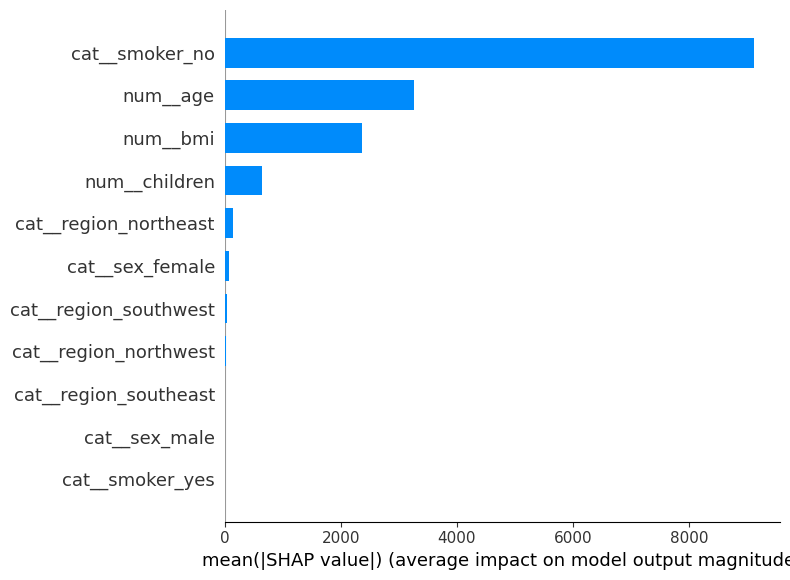

In [48]:
shap.summary_plot(xgb_shap_values, X_test_sample, plot_type="bar")

Bar plot-ul confirmă aceeași ierarhie a importanței variabilelor. Factorul dominant este statutul de fumător, urmat de vârstă și BMI.

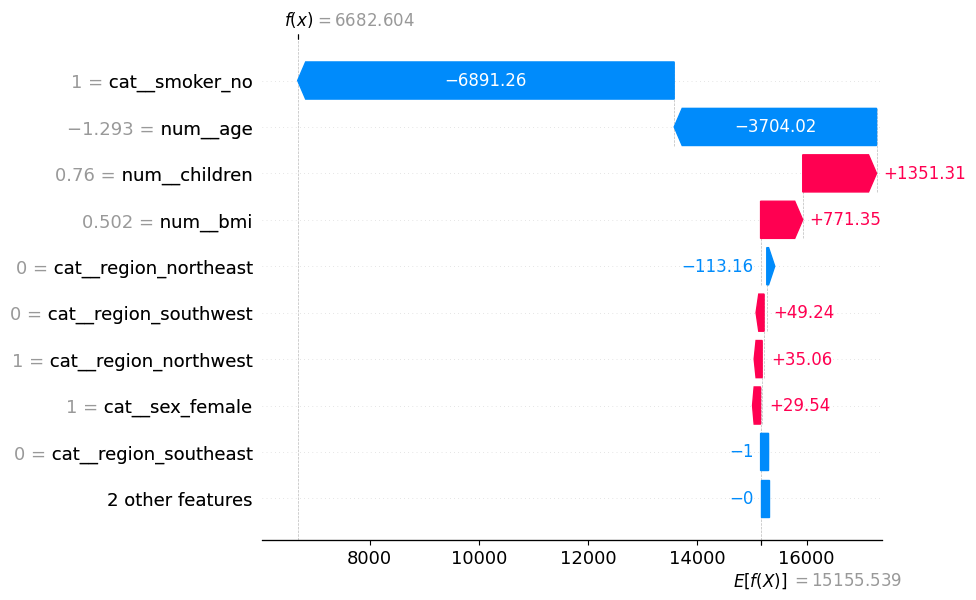

In [49]:
shap.plots.waterfall(xgb_shap_values[0])

### Explicație locală pentru o observație individuală

Pentru exemplul analizat, modelul estimează o valoare finală de aproximativ `6683`.

Factorii care au redus cel mai mult predicția sunt:

- `cat__smoker_no = 1` → persoana este nefumătoare;
- `num__age = -1.293` → vârstă relativ mică.

Factorii care au crescut predicția sunt:

- `num__children = 0.76`
- `num__bmi = 0.502`

Rezultatul final este obținut prin combinarea contribuțiilor individuale ale variabilelor față de valoarea medie de bază.

In [50]:
shap.initjs()
shap.plots.force(xgb_shap_values[0])

Force plot-ul confirmă aceeași interpretare: statutul de nefumător și vârsta redusă trag predicția în jos, în timp ce numărul de copii și BMI o cresc.

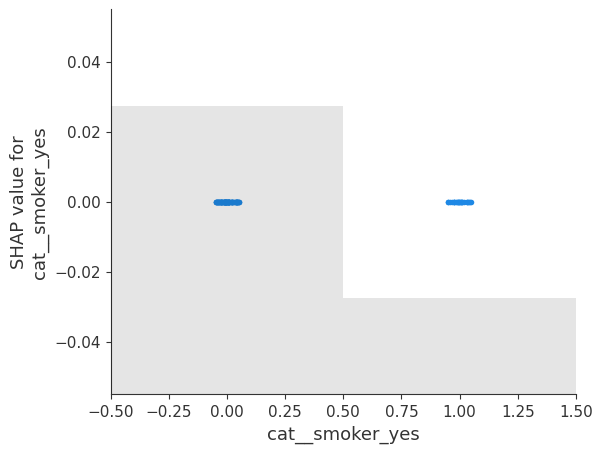

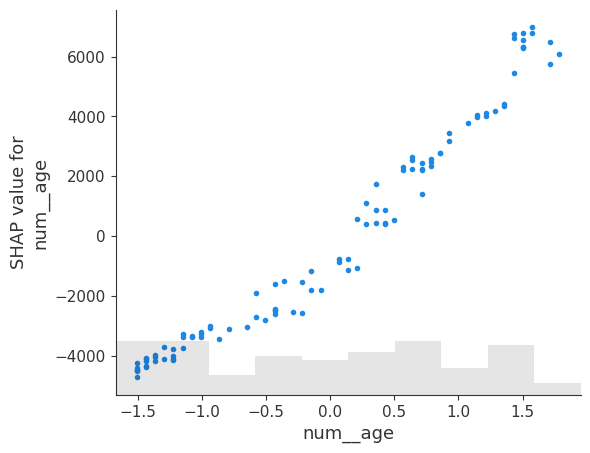

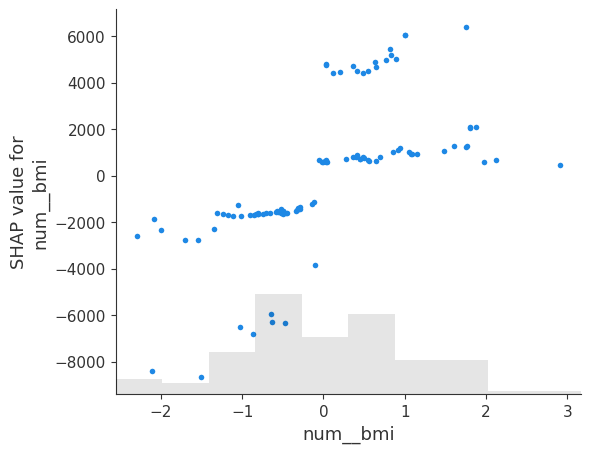

In [51]:
shap.plots.scatter(xgb_shap_values[:, "cat__smoker_yes"])
shap.plots.scatter(xgb_shap_values[:, "num__age"])
shap.plots.scatter(xgb_shap_values[:, "num__bmi"])

### Relația dintre valori și impactul asupra predicției

Scatter plot-urile SHAP evidențiază modul în care variabilele influențează modelul:

- Pentru `age`, impactul crește aproape monoton: persoane mai în vârstă au costuri estimate mai mari.
- Pentru `bmi`, valorile mari tind să crească predicția, iar valorile mici să o reducă.
- Pentru `smoker_yes`, statutul de fumător are efect puternic pozitiv asupra costurilor medicale estimate.

### Concluzie pentru XGBoost

Modelul acordă cea mai mare importanță statutului de fumător, vârstei și indicelui BMI. Acest rezultat este coerent din punct de vedere practic, deoarece acești factori sunt frecvent asociați cu creșterea costurilor medicale.

Explicațiile SHAP confirmă faptul că modelul învață relații realiste și interpretabile.

## 13.2 Analiza SHAP pentru CatBoost Regressor

CatBoost Regressor se numără printre modelele cu cele mai bune performanțe obținute după optimizarea hiperparametrilor. Analiza SHAP este utilizată pentru a evidenția variabilele care influențează predicțiile și modul în care acestea contribuie la estimarea costurilor medicale.

In [52]:
cat_model = fitted_models["CatBoost Regressor"].named_steps["model"]

cat_explainer = shap.Explainer(cat_model, X_test_sample)
cat_shap_values = cat_explainer(X_test_sample)

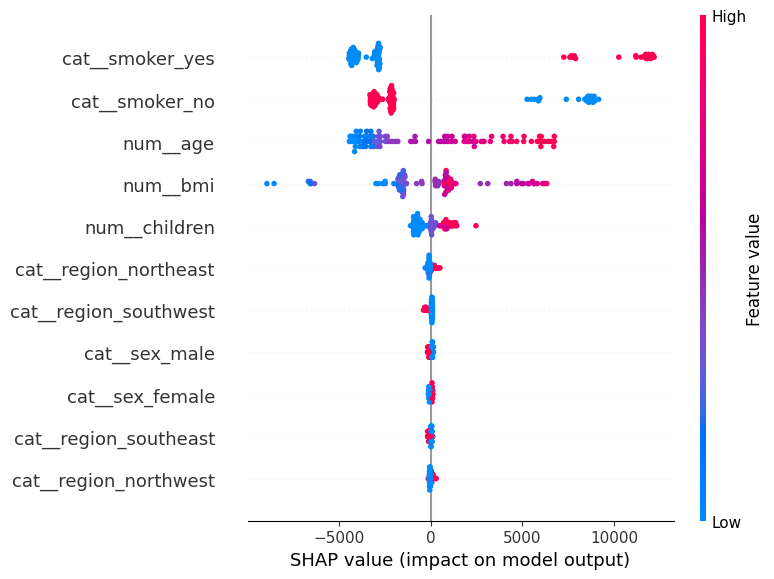

In [53]:
shap.summary_plot(cat_shap_values, X_test_sample)

### Importanța globală a caracteristicilor

Summary plot-ul arată că cele mai importante variabile pentru CatBoost sunt:

1. `cat__smoker_yes`
2. `cat__smoker_no`
3. `num__age`

Imediat după acestea urmează variabila `num__bmi`, iar apoi `num__children`.

Rezultatul confirmă faptul că statutul de fumător reprezintă factorul dominant în estimarea costurilor medicale.

Valorile SHAP pozitive cresc predicția modelului, iar valorile negative o reduc.

Pentru `cat__smoker_yes`, valoarea 1 (persoană fumătoare) împinge puternic predicția în sus, în timp ce valoarea 0 reduce costurile estimate.

Pentru `age`, valorile mari ale vârstei cresc predicția, iar valorile mici o reduc.

Pentru `bmi`, valorile ridicate tind să mărească rezultatul estimat, ceea ce sugerează o relație pozitivă între indicele de masă corporală și cheltuielile medicale.

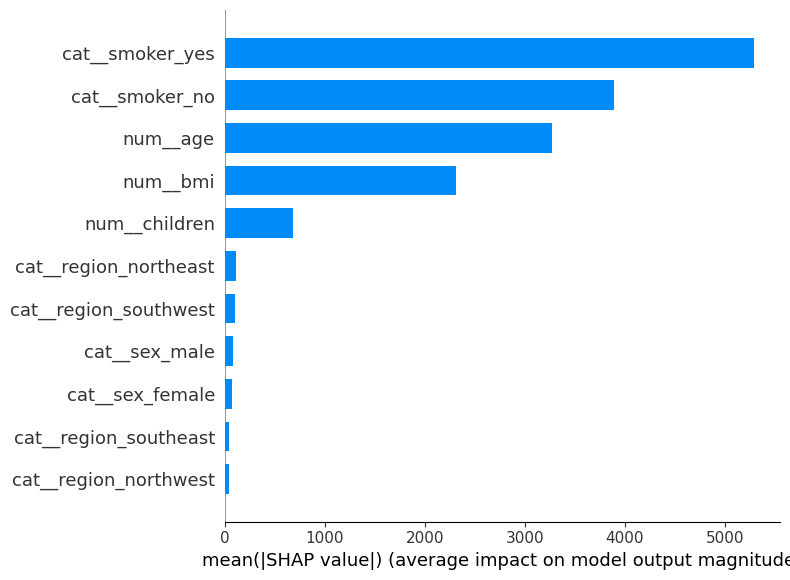

In [54]:
shap.summary_plot(cat_shap_values, X_test_sample, plot_type="bar")

### Confirmarea importanței globale

Bar plot-ul confirmă aceeași ordine a importanței variabilelor. Factorii principali sunt:

- statutul de fumător;
- vârsta;
- BMI;
- numărul de copii.

Variabilele legate de sex și regiune au influență redusă asupra predicției finale.

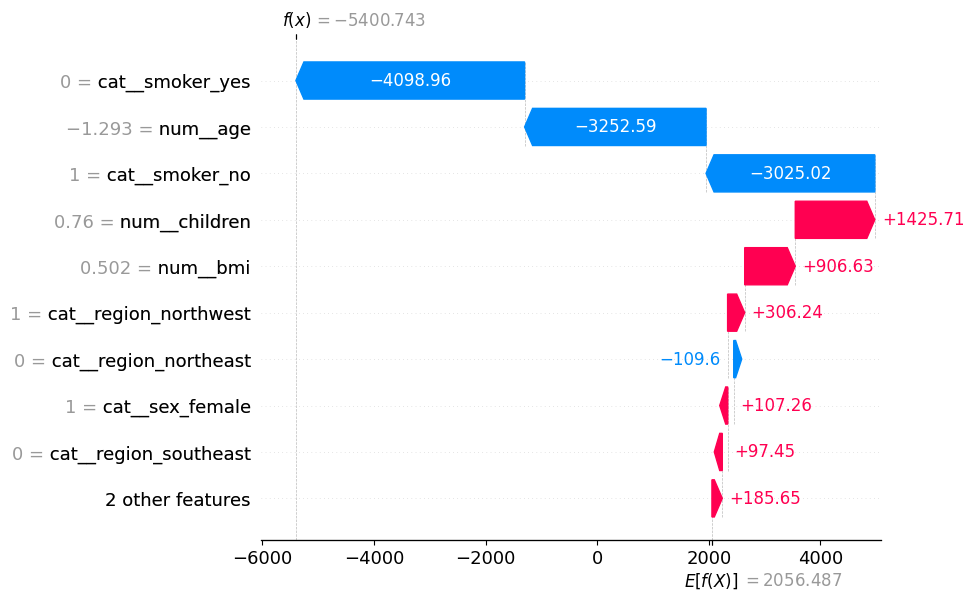

In [55]:
shap.plots.waterfall(cat_shap_values[0])

### Explicație locală pentru o observație individuală

Pentru observația analizată, modelul estimează o valoare finală de aproximativ `-5401` în spațiul intern al modelului explicat de SHAP, pornind de la valoarea medie de bază.

Factorii care reduc cel mai mult predicția sunt:

- `cat__smoker_yes = 0` - persoana nu este fumătoare;
- `num__age = -1.293` - vârstă relativ redusă;
- `cat__smoker_no = 1`.

Factorii care cresc predicția sunt:

- `num__children = 0.760`
- `num__bmi = 0.502`

Acest exemplu arată că lipsa fumatului și vârsta mică pot compensa efectele unor factori care cresc costurile estimate.

In [56]:
shap.initjs()
shap.plots.force(cat_shap_values[0])

### Interpretarea force plot-ului

Force plot-ul confirmă aceeași concluzie: variabilele asociate nefumătorilor și vârstei reduse trag predicția în jos, în timp ce BMI și numărul de copii o cresc.

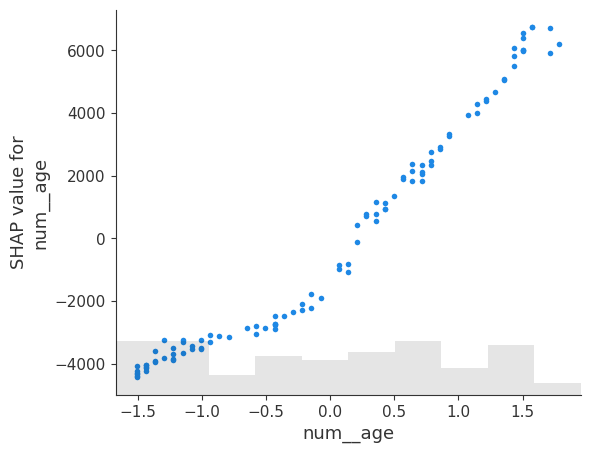

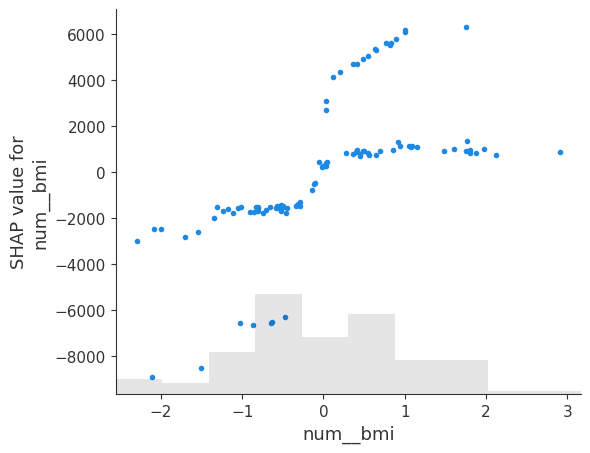

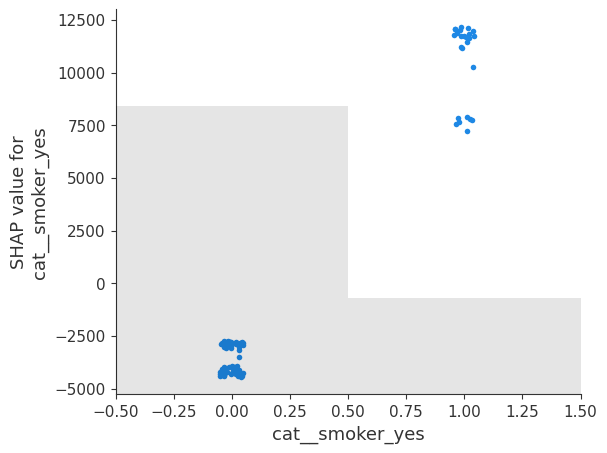

In [57]:
shap.plots.scatter(cat_shap_values[:, "num__age"])
shap.plots.scatter(cat_shap_values[:, "num__bmi"])
shap.plots.scatter(cat_shap_values[:, "cat__smoker_yes"])

### Relația dintre valori și impactul asupra predicției

Scatter plot-urile SHAP evidențiază modul în care valorile caracteristicilor influențează modelul:

- Pentru `age`, impactul crește aproape constant odată cu vârsta. Persoanele mai în vârstă tind să aibă costuri estimate mai mari.
- Pentru `bmi`, valorile mari sunt asociate cu creșterea costurilor medicale estimate.
- Pentru `smoker_yes`, persoanele fumătoare produc un impact pozitiv foarte puternic asupra predicției, semnificativ mai mare decât în cazul nefumătorilor.

### Cele mai importante 3 caracteristici

Conform analizei SHAP, cele mai importante trei variabile pentru CatBoost sunt:

1. Statutul de fumător (`smoker`)
2. Vârsta (`age`)
3. Indicele de masă corporală (`bmi`)

### Concluzie pentru CatBoost

Modelul CatBoost utilizează în principal informațiile legate de fumat, vârstă și BMI pentru estimarea costurilor medicale.

Explicațiile obținute sunt coerente din punct de vedere practic și confirmă faptul că modelul învață relații relevante și interpretabile.

## 13.3 Analiza SHAP pentru Explainable Boosting Regressor

Explainable Boosting Regressor (EBM) este un model construit special pentru a combina performanța predictivă ridicată cu interpretabilitatea. Analiza SHAP este utilizată pentru a observa în mod detaliat ce variabile influențează predicțiile și în ce direcție.

In [58]:
ebm_model = fitted_models["Explainable Boosting Regressor"].named_steps["model"]

ebm_explainer = shap.Explainer(ebm_model.predict, X_test_sample)
ebm_shap_values = ebm_explainer(X_test_sample)

c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
PermutationExplainer explainer: 101it [00:13,  6.51it/s]                        


C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\1542723500.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(ebm_shap_values, X_test_sample)


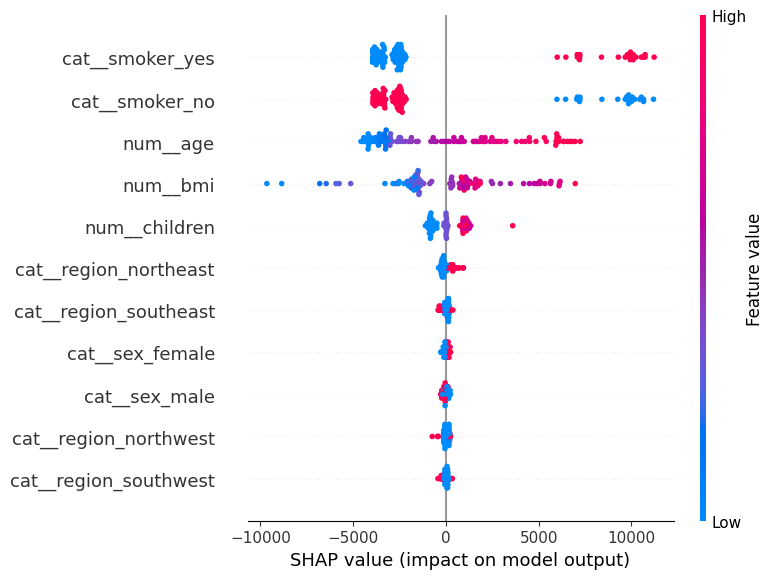

In [59]:
shap.summary_plot(ebm_shap_values, X_test_sample)

### Importanța globală a caracteristicilor

Summary plot-ul evidențiază faptul că cele mai importante variabile pentru acest model sunt:

1. `cat__smoker_yes`
2. `cat__smoker_no`
3. `num__age`

Acestea sunt urmate de:

4. `num__bmi`
5. `num__children`

Rezultatul confirmă faptul că statutul de fumător reprezintă principalul factor asociat costurilor medicale estimate.

Valorile SHAP pozitive cresc predicția modelului, iar valorile negative o reduc.

Pentru `cat__smoker_yes`, valoarea 1 (persoană fumătoare) împinge puternic predicția în sus, în timp ce valoarea 0 o reduce.

Pentru `age`, valorile mari cresc costurile estimate, iar valorile mici reduc predicția.

Pentru `bmi`, valorile ridicate tind să mărească rezultatul final, ceea ce sugerează o influență pozitivă a indicelui de masă corporală asupra cheltuielilor medicale.

C:\Users\Denisa\AppData\Local\Temp\ipykernel_23236\3912774383.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(ebm_shap_values, X_test_sample, plot_type="bar")


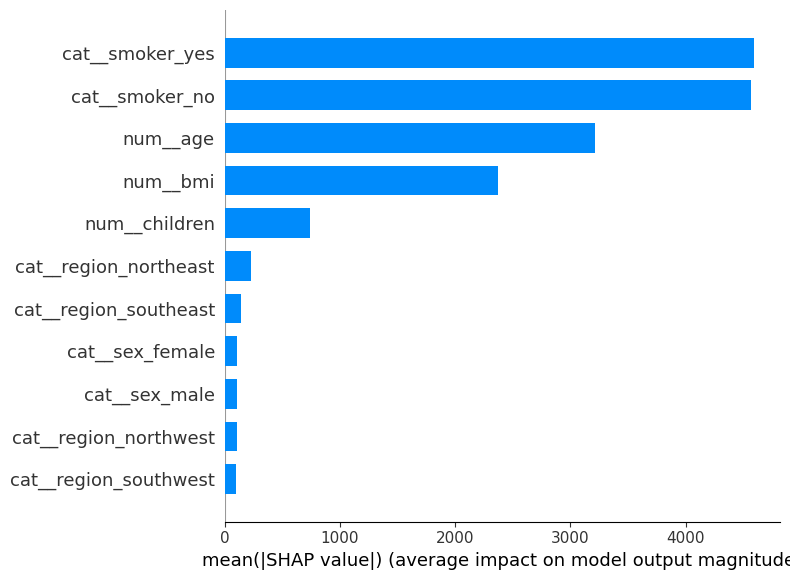

In [60]:
shap.summary_plot(ebm_shap_values, X_test_sample, plot_type="bar")

### Confirmarea importanței globale

Bar plot-ul confirmă aceeași ierarhie a caracteristicilor. Factorii dominanți sunt:

- statutul de fumător;
- vârsta;
- BMI;
- numărul de copii.

Variabilele legate de sex și regiune au influență redusă asupra modelului.

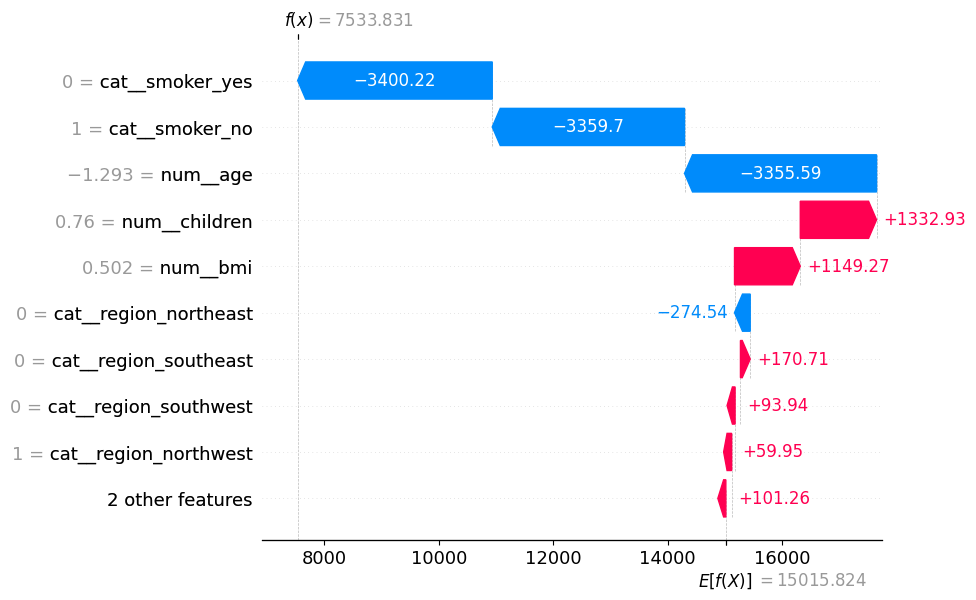

In [61]:
shap.plots.waterfall(ebm_shap_values[0])

### Explicație locală pentru o observație individuală

Pentru observația analizată, modelul estimează o valoare finală de aproximativ `7534`.

Factorii care reduc cel mai mult predicția sunt:

- `cat__smoker_yes = 0`
- `cat__smoker_no = 1`
- `num__age = -1.293`

Factorii care cresc predicția sunt:

- `num__children = 0.760`
- `num__bmi = 0.502`

Acest rezultat sugerează că persoana analizată este nefumătoare și relativ tânără, ceea ce reduce costurile estimate, însă BMI și numărul de copii contribuie pozitiv.

In [62]:
shap.initjs()
shap.plots.force(ebm_shap_values[0])

### Interpretarea force plot-ului

Force plot-ul confirmă aceeași concluzie: lipsa fumatului și vârsta redusă trag predicția în jos, în timp ce BMI și numărul de copii o cresc.

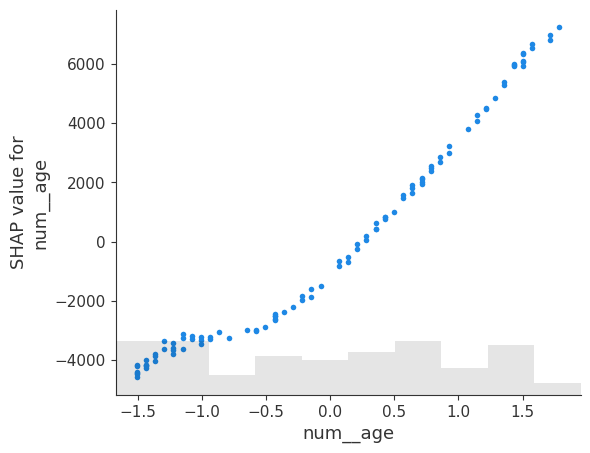

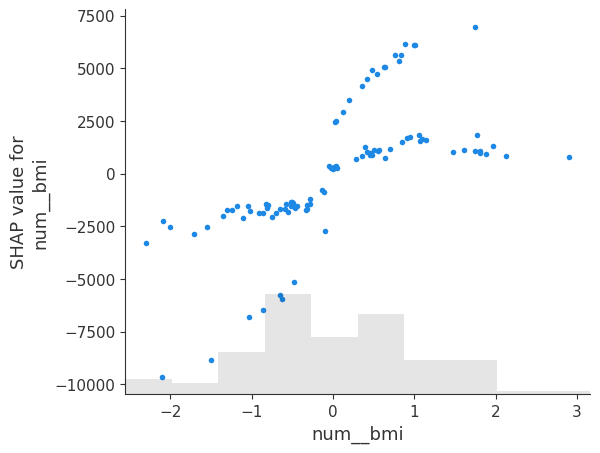

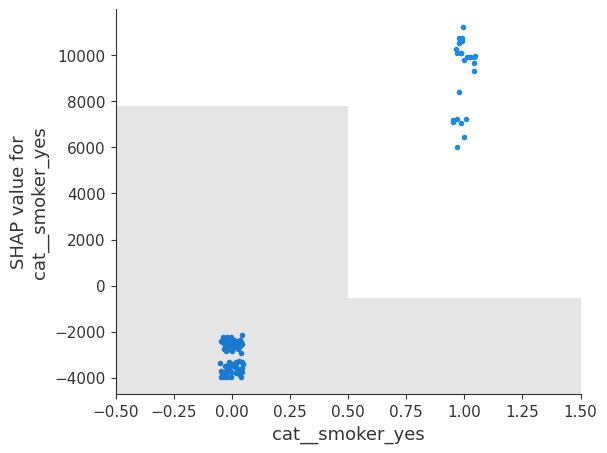

In [63]:
shap.plots.scatter(ebm_shap_values[:, "num__age"])
shap.plots.scatter(ebm_shap_values[:, "num__bmi"])
shap.plots.scatter(ebm_shap_values[:, "cat__smoker_yes"])

### Relația dintre valori și impactul asupra predicției

Scatter plot-urile SHAP evidențiază relații clare între caracteristici și predicții:

- Pentru `age`, impactul crește constant odată cu vârsta. Persoanele mai în vârstă tind să aibă costuri medicale estimate mai ridicate.
- Pentru `bmi`, valorile mari sunt asociate cu o creștere accentuată a costurilor estimate.
- Pentru `smoker_yes`, persoanele fumătoare au un impact pozitiv foarte puternic asupra predicției, semnificativ mai mare decât nefumătorii.

### Cele mai importante 3 caracteristici

Conform analizei SHAP, cele mai importante trei variabile pentru Explainable Boosting Regressor sunt:

1. Statutul de fumător (`smoker`)
2. Vârsta (`age`)
3. Indicele de masă corporală (`bmi`)

### Concluzie pentru Explainable Boosting Regressor

Modelul Explainable Boosting Regressor utilizează în principal informațiile legate de fumat, vârstă și BMI pentru estimarea costurilor medicale.

Rezultatele sunt coerente din punct de vedere practic și confirmă faptul că modelul reușește să surprindă relații relevante și ușor de interpretat.

## 13.4 Concluzii generale ale analizei SHAP

Analiza SHAP a fost realizată pentru primele trei modele perfecționate:

1. XGBoost Regressor  
2. CatBoost Regressor  
3. Explainable Boosting Regressor  

Rezultatele obținute sunt consistente între modele și evidențiază aceiași factori principali care influențează costurile medicale estimate.

### Cele mai importante caracteristici identificate

În majoritatea analizelor, variabilele dominante sunt:

1. Statutul de fumător (`smoker`)
2. Vârsta (`age`)
3. Indicele de masă corporală (`bmi`)

Aceste caracteristici apar constant în primele poziții atât în summary plot-uri, cât și în bar plot-uri.

### Interpretarea influenței variabilelor

- Persoanele fumătoare tind să aibă costuri medicale estimate semnificativ mai mari.
- O vârstă mai ridicată conduce, în general, la creșterea predicției.
- Valorile mari ale BMI sunt asociate cu cheltuieli medicale mai ridicate.
- Numărul de copii are o influență moderată pozitivă.
- Sexul și regiunea au impact redus în comparație cu ceilalți factori.

### Explicații locale ale predicțiilor

Graficele de tip waterfall și force plot au arătat modul în care fiecare caracteristică contribuie la o predicție individuală.

Pentru exemplele analizate, statutul de nefumător și vârsta redusă au tras predicția în jos, în timp ce BMI ridicat sau numărul de copii au împins predicția în sus.

### Compararea modelelor

Toate cele trei modele învață relații similare între variabile și costurile medicale, ceea ce oferă încredere suplimentară în rezultatele obținute.

Diferențele dintre modele apar mai ales la nivelul performanței predictive, nu în interpretarea factorilor importanți.

### Concluzie finală

Analiza SHAP confirmă faptul că modelele perfecționate nu oferă doar predicții precise, ci și explicații coerente și interpretabile.

Rezultatele sunt relevante din punct de vedere practic și arată că factorii principali asociați costurilor medicale sunt fumatul, vârsta și indicele de masă corporală.

## 14. Salvarea modelelor finale 

In [70]:
import joblib
import os
from sklearn.pipeline import Pipeline

os.makedirs("../models/regression", exist_ok=True)

xgb_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])

cat_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_cat)
])

ebm_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_ebm)
])

rf_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

lin_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_lin)
])

xgb_final.fit(X_train, y_train)
cat_final.fit(X_train, y_train)
ebm_final.fit(X_train, y_train)
rf_final.fit(X_train, y_train)
lin_final.fit(X_train, y_train)

joblib.dump(xgb_final, "../models/regression/xgboost_model.pkl")
joblib.dump(cat_final, "../models/regression/catboost_model.pkl")
joblib.dump(ebm_final, "../models/regression/ebm_model.pkl")
joblib.dump(rf_final, "../models/regression/random_forest_model.pkl")
joblib.dump(lin_final, "../models/regression/linear_regression_model.pkl")

['../models/regression/linear_regression_model.pkl']

La fel ca în notebook-ul de clasificare, și în acest notebook am folosit bibliotecile `joblib` și `os` pentru salvarea și organizarea modelelor de regresie.